In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cs-training.csv')
print(df.shape)
print(df.head())

(150000, 12)
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13      

In [ ]:
print(df.isnull().sum())
print('---')
print(df.describe())

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64
---
          Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
count  150000.000000     150000.000000                         150000.000000   
mean    75000.500000          0.066840                              6.048438   
std     43301.414527          0.249746                            249.755371   
min         1.000000          0.000000                              0.000000   
25%     37500.750000          0

In [ ]:
# Fill missing values
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)

# Confirm no missing values remain
print(df.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


/tmp/ipykernel_1691/1150840927.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
/tmp/ipykernel_1691/1150840927.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

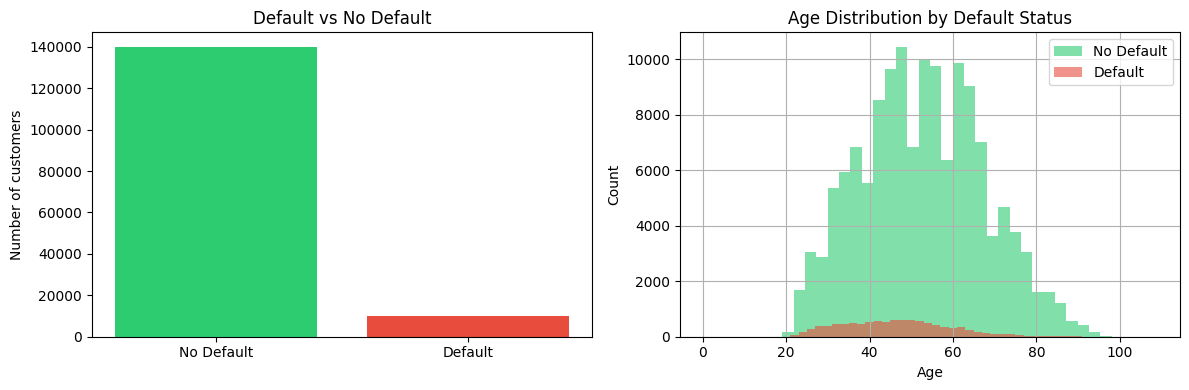

In [ ]:
# Default rate overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: How many defaulted?
default_counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(['No Default', 'Default'], default_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Default vs No Default')
axes[0].set_ylabel('Number of customers')

# Chart 2: Age distribution by default
df[df['SeriousDlqin2yrs']==0]['age'].hist(ax=axes[1], alpha=0.6, color='#2ecc71', label='No Default', bins=40)
df[df['SeriousDlqin2yrs']==1]['age'].hist(ax=axes[1], alpha=0.6, color='#e74c3c', label='Default', bins=40)
axes[1].set_title('Age Distribution by Default Status')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

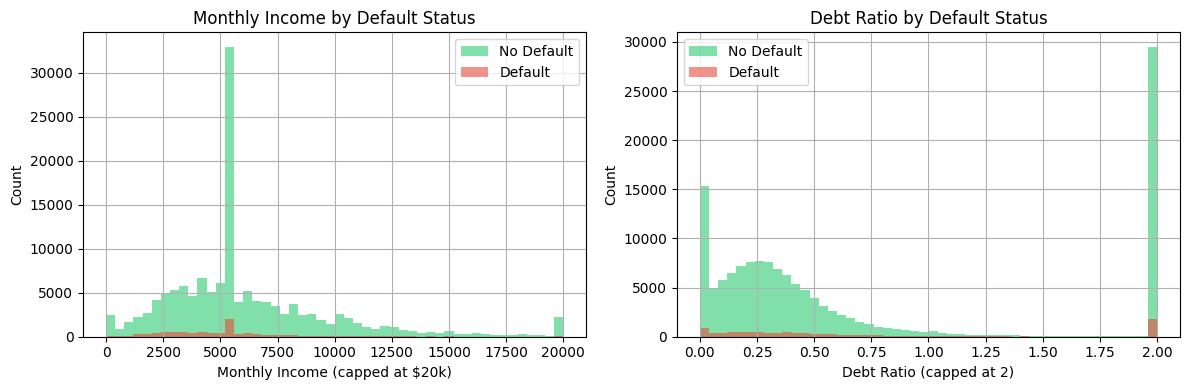

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 3: Monthly income by default status
df[df['SeriousDlqin2yrs']==0]['MonthlyIncome'].clip(upper=20000).hist(
    ax=axes[0], alpha=0.6, color='#2ecc71', label='No Default', bins=50)
df[df['SeriousDlqin2yrs']==1]['MonthlyIncome'].clip(upper=20000).hist(
    ax=axes[0], alpha=0.6, color='#e74c3c', label='Default', bins=50)
axes[0].set_title('Monthly Income by Default Status')
axes[0].set_xlabel('Monthly Income (capped at $20k)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Chart 4: Debt ratio by default status
df[df['SeriousDlqin2yrs']==0]['DebtRatio'].clip(upper=2).hist(
    ax=axes[1], alpha=0.6, color='#2ecc71', label='No Default', bins=50)
df[df['SeriousDlqin2yrs']==1]['DebtRatio'].clip(upper=2).hist(
    ax=axes[1], alpha=0.6, color='#e74c3c', label='Default', bins=50)
axes[1].set_title('Debt Ratio by Default Status')
axes[1].set_xlabel('Debt Ratio (capped at 2)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

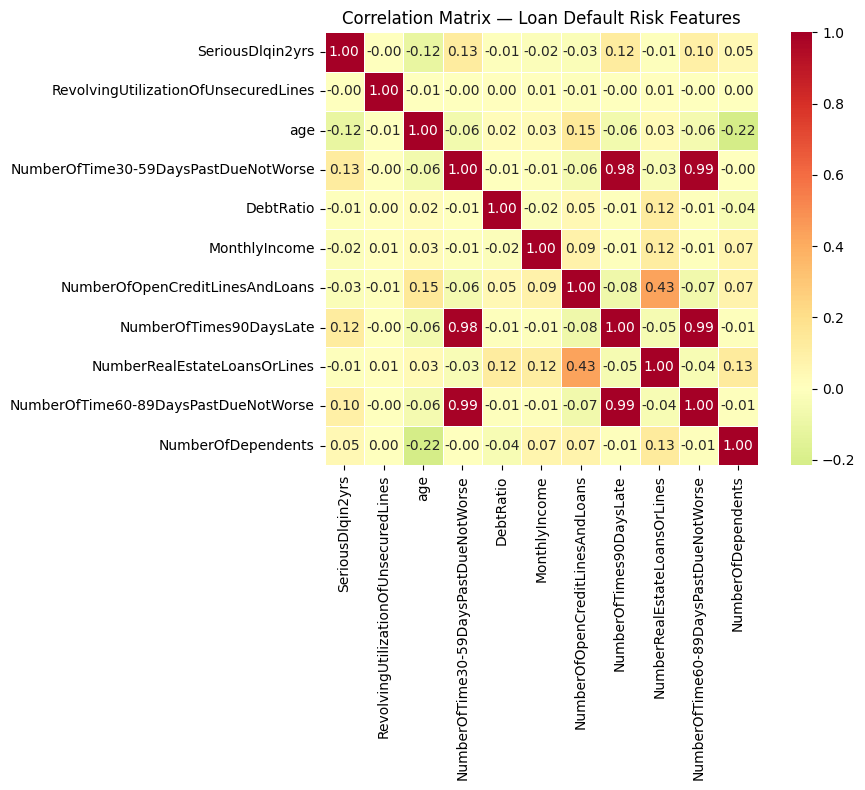

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop('Unnamed: 0', axis=1).corr()
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Matrix — Loan Default Risk Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Prepare data
features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse',
            'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

X = df[features]
y = df['SeriousDlqin2yrs']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     28044
           1       0.53      0.01      0.03      1956

    accuracy                           0.93     30000
   macro avg       0.73      0.51      0.50     30000
weighted avg       0.91      0.93      0.91     30000

Confusion Matrix:
[[28018    26]
 [ 1927    29]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.94      0.99      0.97     28044
           1       0.55      0.15      0.24      1956

    accuracy                           0.94     30000
   macro avg       0.74      0.57      0.60     30000
weighted avg       0.92      0.94      0.92     30000



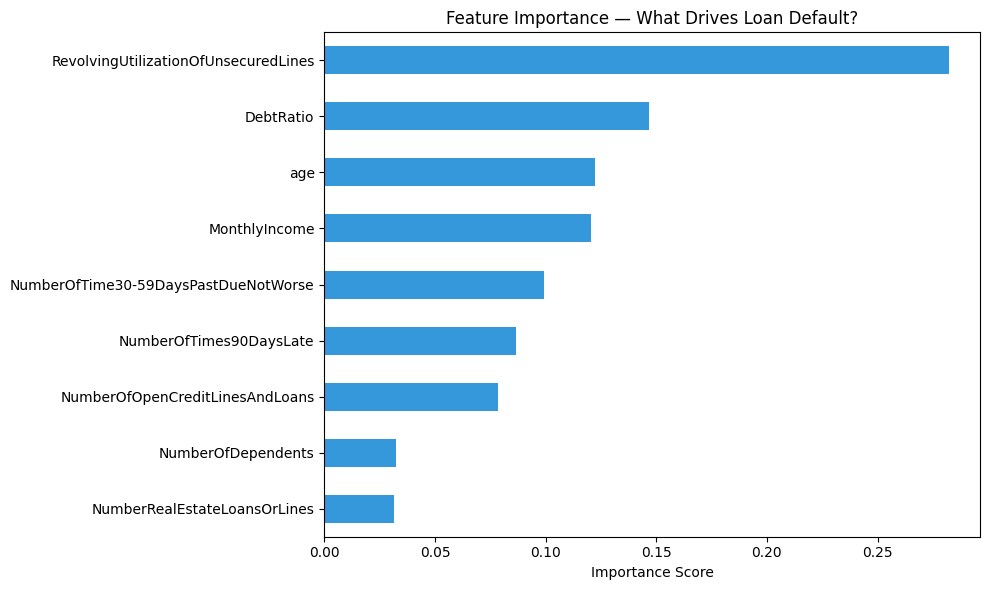

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Better model - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

# Feature importance chart
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='#3498db')
plt.title('Feature Importance — What Drives Loan Default?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Export for Power BI dashboard
export_df = df[['SeriousDlqin2yrs', 'age', 'MonthlyIncome', 'DebtRatio',
                'RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate']].copy()

export_df['AgeGroup'] = pd.cut(df['age'],
                                bins=[0, 30, 40, 50, 60, 100],
                                labels=['<30', '30-40', '40-50', '50-60', '60+'])

export_df['IncomeGroup'] = pd.cut(df['MonthlyIncome'],
                                   bins=[0, 3000, 6000, 10000, 999999],
                                   labels=['Low', 'Medium', 'High', 'Very High'])

export_df.to_csv('loan_default_for_powerbi.csv', index=False)
print('Exported successfully!')
print(export_df.head())

Exported successfully!
   SeriousDlqin2yrs  age  MonthlyIncome  DebtRatio  \
0                 1   45         9120.0   0.802982   
1                 0   40         2600.0   0.121876   
2                 0   38         3042.0   0.085113   
3                 0   30         3300.0   0.036050   
4                 0   49        63588.0   0.024926   

   RevolvingUtilizationOfUnsecuredLines  NumberOfTimes90DaysLate AgeGroup  \
0                              0.766127                        0    40-50   
1                              0.957151                        0    30-40   
2                              0.658180                        1    30-40   
3                              0.233810                        0      <30   
4                              0.907239                        0    40-50   

  IncomeGroup  
0        High  
1         Low  
2      Medium  
3      Medium  
4   Very High  
